# 淘宝展示广告投放效果分析

## 项目背景

本项目基于淘宝展示广告数据，结合用户画像、广告属性和曝光点击日志，分析不同渠道、投放时段、用户群体及商品特征的点击表现，为广告预算分配、用户定向和商品投放优化提供数据依据。

数据覆盖2017年5月6日至5月13日，共包含26,557,961次广告曝光、1,366,056次点击、1,061,768名用户和846,811条广告记录，整体点击率为5.1437%。

## 分析目标

* 评估不同广告渠道和投放时段的点击效率。
* 识别点击倾向较高的用户群体。
* 分析商品价格、品牌信息和商品品类与CTR的关系。
* 通过统计检验判断关键CTR差异是否由随机波动造成。
* 根据分析结果提出可执行的广告投放优化建议。

## 核心指标

本项目以点击率（Click-Through Rate，CTR）作为衡量广告点击效率的核心指标：

$$
\text{CTR}=\frac{\text{Clicks}}{\text{Impressions}}
$$

由于数据中不包含订单、广告成本和销售收入，本项目仅分析广告点击效率，不直接评价转化率、获客成本或广告投入产出比。

In [1]:
from pathlib import Path
import tarfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid")

In [2]:
USER_PATH = "user_profile.csv"
AD_PATH = "ad_feature.csv"
user_profile = pd.read_csv(USER_PATH)
ad_feature = pd.read_csv(AD_PATH)

# 清除字段名两端的空格
user_profile.columns = user_profile.columns.str.strip()
ad_feature.columns = ad_feature.columns.str.strip()

print("用户画像表形状：", user_profile.shape)
print("广告属性表形状：", ad_feature.shape)

display(user_profile.head())
display(ad_feature.head())

用户画像表形状： (1061768, 9)
广告属性表形状： (846811, 6)


,userid,cms_segid,cms_group_id,final_gender_code,age_level,pvalue_level,shopping_level,occupation,new_user_class_level
0,234,0,5,2,5,NaN,3,0,3.0000
1,523,5,2,2,2,1.0000,3,1,2.0000
2,612,0,8,1,2,2.0000,3,0,NaN
3,1670,0,4,2,4,NaN,1,0,NaN
4,2545,0,10,1,4,NaN,3,0,NaN


,adgroup_id,cate_id,campaign_id,customer,brand,price
0,63133,6406,83237,1,"95,471.0000",170.0000
1,313401,6406,83237,1,"87,331.0000",199.0000
2,248909,392,83237,1,"32,233.0000",38.0000
3,208458,392,83237,1,"174,374.0000",139.0000
4,110847,7211,135256,2,"145,952.0000",32.9900


## 1. 数据概览与质量检查

本部分检查用户画像表、广告属性表和曝光日志的字段结构、数据规模、主键重复、缺失值及异常值，并核对曝光量、点击量、整体CTR和数据时间范围，为后续分析建立可靠的数据基础。

In [3]:
def audit_table(data, key_column):
    audit_result = pd.DataFrame({
        "数据类型": data.dtypes.astype(str),
        "缺失数量": data.isna().sum(),
        "缺失率": data.isna().mean(),
        "唯一值数量": data.nunique(dropna=True)
    })

    print(f"数据行数：{len(data):,}")
    print(f"完全重复行：{data.duplicated().sum():,}")
    print(f"{key_column}重复数量：{data[key_column].duplicated().sum():,}")

    return audit_result

In [4]:
user_audit = audit_table(
    data=user_profile,
    key_column="userid"
)

display(
    user_audit.style.format({
        "缺失数量": "{:,.0f}",
        "缺失率": "{:.2%}",
        "唯一值数量": "{:,.0f}"
    })
)

数据行数：1,061,768
完全重复行：0
userid重复数量：0


,数据类型,缺失数量,缺失率,唯一值数量
userid,int64,0,0.00%,"1,061,768"
cms_segid,int64,0,0.00%,97
cms_group_id,int64,0,0.00%,13
final_gender_code,int64,0,0.00%,2
age_level,int64,0,0.00%,7
pvalue_level,float64,"575,917",54.24%,3
shopping_level,int64,0,0.00%,3
occupation,int64,0,0.00%,2
new_user_class_level,float64,"344,920",32.49%,4


In [5]:
ad_audit = audit_table(
    data=ad_feature,
    key_column="adgroup_id"
)

display(
    ad_audit.style.format({
        "缺失数量": "{:,.0f}",
        "缺失率": "{:.2%}",
        "唯一值数量": "{:,.0f}"
    })
)

数据行数：846,811
完全重复行：0
adgroup_id重复数量：0


,数据类型,缺失数量,缺失率,唯一值数量
adgroup_id,int64,0,0.00%,"846,811"
cate_id,int64,0,0.00%,"6,769"
campaign_id,int64,0,0.00%,"423,436"
customer,int64,0,0.00%,"255,875"
brand,float64,"246,330",29.09%,"99,814"
price,float64,0,0.00%,"14,861"


In [6]:
price_summary = ad_feature["price"].describe(
    percentiles=[0.01, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999]
)

display(price_summary.to_frame("price"))

,price
count,"846,811.0000"
mean,"1,838.8671"
std,"310,887.6973"
min,0.0100
1%,1.1000
25%,49.0000
50%,139.0000
75%,352.0000
95%,"2,188.0000"
99%,"8,720.0000"


In [7]:
RAW_PATH = "raw_sample.csv.tar.gz"

profile_user_ids = set(user_profile["userid"])
valid_adgroup_ids = set(ad_feature["adgroup_id"])

total_rows = 0
total_clicks = 0
total_nonclicks = 0
invalid_label_rows = 0

matched_user_rows = 0
matched_ad_rows = 0

unique_users = set()
unique_adgroups = set()

min_timestamp = None
max_timestamp = None

with tarfile.open(RAW_PATH, mode="r:gz") as tar:
    raw_member = next(
        member for member in tar.getmembers()
        if member.name.endswith("raw_sample.csv")
    )

    raw_file = tar.extractfile(raw_member)

    for chunk_number, chunk in enumerate(
        pd.read_csv(raw_file, chunksize=1_000_000),
        start=1
    ):
        total_rows += len(chunk)
        total_clicks += int(chunk["clk"].sum())
        total_nonclicks += int(chunk["nonclk"].sum())

        # 检查clk和nonclk是否互斥
        invalid_label_rows += int(
            ((chunk["clk"] + chunk["nonclk"]) != 1).sum()
        )

        unique_users.update(chunk["user"].unique())
        unique_adgroups.update(chunk["adgroup_id"].unique())

        matched_user_rows += int(
            chunk["user"].isin(profile_user_ids).sum()
        )

        matched_ad_rows += int(
            chunk["adgroup_id"].isin(valid_adgroup_ids).sum()
        )

        chunk_min_time = int(chunk["time_stamp"].min())
        chunk_max_time = int(chunk["time_stamp"].max())

        if min_timestamp is None:
            min_timestamp = chunk_min_time
            max_timestamp = chunk_max_time
        else:
            min_timestamp = min(min_timestamp, chunk_min_time)
            max_timestamp = max(max_timestamp, chunk_max_time)

        print(
            f"\r已处理：{total_rows:,} 条曝光记录",
            end=""
        )

print("\n完整曝光日志读取完成。")

已处理：26,557,961 条曝光记录
完整曝光日志读取完成。


In [8]:
start_time = (
    pd.to_datetime(min_timestamp, unit="s", utc=True)
    .tz_convert("Asia/Shanghai")
)

end_time = (
    pd.to_datetime(max_timestamp, unit="s", utc=True)
    .tz_convert("Asia/Shanghai")
)

overall_ctr = total_clicks / total_rows
user_match_rate = matched_user_rows / total_rows
ad_match_rate = matched_ad_rows / total_rows

raw_summary = pd.DataFrame({
    "指标": [
        "曝光记录数",
        "点击次数",
        "未点击次数",
        "整体CTR",
        "独立用户数",
        "独立广告数",
        "用户画像匹配率",
        "广告属性匹配率",
        "标签异常记录数",
        "开始时间（北京时间）",
        "结束时间（北京时间）"
    ],
    "结果": [
        f"{total_rows:,}",
        f"{total_clicks:,}",
        f"{total_nonclicks:,}",
        f"{overall_ctr:.4%}",
        f"{len(unique_users):,}",
        f"{len(unique_adgroups):,}",
        f"{user_match_rate:.4%}",
        f"{ad_match_rate:.4%}",
        f"{invalid_label_rows:,}",
        start_time.strftime("%Y-%m-%d %H:%M:%S"),
        end_time.strftime("%Y-%m-%d %H:%M:%S")
    ]
})

display(raw_summary)

,指标,结果
0,曝光记录数,"26,557,961"
1,点击次数,"1,366,056"
2,未点击次数,"25,191,905"
3,整体CTR,5.1437%
4,独立用户数,"1,141,729"
5,独立广告数,"846,811"
6,用户画像匹配率,94.2446%
7,广告属性匹配率,100.0000%
8,标签异常记录数,0
9,开始时间（北京时间）,2017-05-06 00:00:00


## 2. 数据清洗与特征构造

用户画像中的缺失类别被统一标记，避免直接删除缺失数据造成样本选择偏差。广告价格采用99.9%分位数进行缩尾处理，以降低极端价格对分组分析的影响。

曝光日志中的Unix时间戳被转换为北京时间，并进一步构造日期、小时、星期和周末标记。考虑到曝光日志规模较大，完整数据采用分块读取方式处理，随后分别与用户画像表和广告属性表进行多对一关联。

关联完成后，再次核对曝光量和点击量，确保数据关联没有造成记录丢失或重复。


In [9]:
user_clean = user_profile.copy()

# 与曝光日志中的user字段保持一致
user_clean = user_clean.rename(columns={"userid": "user"})

user_missing_columns = [
    "pvalue_level",
    "new_user_class_level"
]

for column in user_missing_columns:
    # 保留缺失标记，1表示原始数据缺失
    user_clean[f"{column}_missing"] = (
        user_clean[column].isna().astype("int8")
    )

    # 使用-1表示未知类别
    user_clean[column] = (
        user_clean[column]
        .fillna(-1)
        .astype("int8")
    )

print("清洗后用户表形状：", user_clean.shape)
print("用户表剩余缺失值：", user_clean.isna().sum().sum())

display(user_clean.head())

清洗后用户表形状： (1061768, 11)
用户表剩余缺失值： 0


,user,cms_segid,cms_group_id,final_gender_code,age_level,pvalue_level,shopping_level,occupation,new_user_class_level,pvalue_level_missing,new_user_class_level_missing
0,234,0,5,2,5,-1,3,0,3,1,0
1,523,5,2,2,2,1,3,1,2,0,0
2,612,0,8,1,2,2,3,0,-1,0,1
3,1670,0,4,2,4,-1,1,0,-1,1,1
4,2545,0,10,1,4,-1,3,0,-1,1,1


In [10]:
ad_clean = ad_feature.copy()

# 字段命名更加明确
ad_clean = ad_clean.rename(
    columns={"customer": "customer_id"}
)

# 品牌缺失标记
ad_clean["brand_missing"] = (
    ad_clean["brand"].isna().astype("int8")
)

# -1表示未知品牌
ad_clean["brand"] = (
    ad_clean["brand"]
    .fillna(-1)
    .astype("int64")
)

# 使用99.9%分位数作为价格缩尾上限
price_upper_limit = ad_clean["price"].quantile(0.999)

# 保留原始price，同时增加处理后的价格
ad_clean["price_capped"] = (
    ad_clean["price"].clip(upper=price_upper_limit)
)

ad_clean["log_price"] = np.log1p(
    ad_clean["price_capped"]
)

# 构造便于业务解释的价格区间
ad_clean["price_bin"] = pd.cut(
    ad_clean["price"],
    bins=[
        -np.inf,
        50,
        150,
        500,
        2000,
        10000,
        np.inf
    ],
    labels=[
        "50元以下",
        "50-149元",
        "150-499元",
        "500-1999元",
        "2000-9999元",
        "10000元及以上"
    ],
    right=False
)

print("清洗后广告表形状：", ad_clean.shape)
print("广告表剩余缺失值：", ad_clean.isna().sum().sum())
print(f"价格缩尾上限：{price_upper_limit:,.2f}")

display(
    ad_clean[
        [
            "adgroup_id",
            "cate_id",
            "campaign_id",
            "customer_id",
            "brand",
            "brand_missing",
            "price",
            "price_capped",
            "log_price",
            "price_bin"
        ]
    ].head()
)

清洗后广告表形状： (846811, 10)
广告表剩余缺失值： 0
价格缩尾上限：51,006.84


,adgroup_id,cate_id,campaign_id,customer_id,brand,brand_missing,price,price_capped,log_price,price_bin
0,63133,6406,83237,1,95471,0,170.0000,170.0000,5.1417,150-499元
1,313401,6406,83237,1,87331,0,199.0000,199.0000,5.2983,150-499元
2,248909,392,83237,1,32233,0,38.0000,38.0000,3.6636,50元以下
3,208458,392,83237,1,174374,0,139.0000,139.0000,4.9416,50-149元
4,110847,7211,135256,2,145952,0,32.9900,32.9900,3.5261,50元以下


In [11]:
with tarfile.open(RAW_PATH, mode="r:gz") as tar:
    raw_member = next(
        member for member in tar.getmembers()
        if member.name.endswith("raw_sample.csv")
    )

    raw_file = tar.extractfile(raw_member)

    exposure_sample = pd.read_csv(
        raw_file,
        nrows=1_000_000
    )

# 转换为北京时间
exposure_sample["datetime"] = (
    pd.to_datetime(
        exposure_sample["time_stamp"],
        unit="s",
        utc=True
    )
    .dt.tz_convert("Asia/Shanghai")
)

# 构造时间特征
exposure_sample["date"] = (
    exposure_sample["datetime"].dt.date
)

exposure_sample["hour"] = (
    exposure_sample["datetime"].dt.hour.astype("int8")
)

exposure_sample["weekday"] = (
    exposure_sample["datetime"].dt.weekday.astype("int8")
)

weekday_mapping = {
    0: "周一",
    1: "周二",
    2: "周三",
    3: "周四",
    4: "周五",
    5: "周六",
    6: "周日"
}

exposure_sample["weekday_name"] = (
    exposure_sample["weekday"].map(weekday_mapping)
)

exposure_sample["is_weekend"] = (
    exposure_sample["weekday"]
    .isin([5, 6])
    .astype("int8")
)

print("曝光样本形状：", exposure_sample.shape)
print(
    "北京时间范围：",
    exposure_sample["datetime"].min(),
    "至",
    exposure_sample["datetime"].max()
)

display(exposure_sample.head())

曝光样本形状： (1000000, 12)
北京时间范围： 2017-05-06 00:00:00+08:00 至 2017-05-13 23:59:35+08:00


,user,time_stamp,adgroup_id,pid,nonclk,clk,datetime,date,hour,weekday,weekday_name,is_weekend
0,581738,1494137644,1,430548_1007,1,0,2017-05-07 14:14:04+08:00,2017-05-07,14,6,周日,1
1,449818,1494638778,3,430548_1007,1,0,2017-05-13 09:26:18+08:00,2017-05-13,9,5,周六,1
2,914836,1494650879,4,430548_1007,1,0,2017-05-13 12:47:59+08:00,2017-05-13,12,5,周六,1
3,914836,1494651029,5,430548_1007,1,0,2017-05-13 12:50:29+08:00,2017-05-13,12,5,周六,1
4,399907,1494302958,8,430548_1007,1,0,2017-05-09 12:09:18+08:00,2017-05-09,12,1,周二,0


In [12]:
rows_before_merge = len(exposure_sample)
clicks_before_merge = exposure_sample["clk"].sum()

sample_merged = exposure_sample.merge(
    user_clean,
    on="user",
    how="left",
    validate="many_to_one",
    indicator="user_merge_status"
)

sample_merged = sample_merged.merge(
    ad_clean,
    on="adgroup_id",
    how="left",
    validate="many_to_one",
    indicator="ad_merge_status"
)

rows_after_merge = len(sample_merged)
clicks_after_merge = sample_merged["clk"].sum()

user_sample_match_rate = (
    sample_merged["user_merge_status"]
    .eq("both")
    .mean()
)

ad_sample_match_rate = (
    sample_merged["ad_merge_status"]
    .eq("both")
    .mean()
)

merge_validation = pd.DataFrame({
    "检查项目": [
        "关联前曝光量",
        "关联后曝光量",
        "关联前点击量",
        "关联后点击量",
        "用户画像匹配率",
        "广告属性匹配率"
    ],
    "结果": [
        f"{rows_before_merge:,}",
        f"{rows_after_merge:,}",
        f"{clicks_before_merge:,}",
        f"{clicks_after_merge:,}",
        f"{user_sample_match_rate:.4%}",
        f"{ad_sample_match_rate:.4%}"
    ]
})

display(merge_validation)

assert rows_before_merge == rows_after_merge
assert clicks_before_merge == clicks_after_merge

print("关联验证通过：曝光量和点击量均未发生变化。")

,检查项目,结果
0,关联前曝光量,"1,000,000"
1,关联后曝光量,"1,000,000"
2,关联前点击量,"49,493"
3,关联后点击量,"49,493"
4,用户画像匹配率,94.1772%
5,广告属性匹配率,100.0000%


关联验证通过：曝光量和点击量均未发生变化。


In [13]:
# 后续需要分析的分组字段
group_columns = [
    "pid",
    "date",
    "hour",
    "weekday",
    "is_weekend",
    "user_profile_matched",
    "final_gender_code",
    "age_level",
    "pvalue_level",
    "shopping_level",
    "occupation",
    "new_user_class_level",
    "ad_feature_matched",
    "price_bin",
    "brand_missing",
    "cate_id",
    "campaign_id",
    "customer_id",
    "brand",
    "adgroup_id"
]

# 用于存储各维度的曝光量和点击量
group_metrics = {}


def update_group_metrics(storage, data, group_column):
    grouped = (
        data.groupby(
            group_column,
            dropna=False,
            observed=True
        )["clk"]
        .agg(["size", "sum"])
        .rename(
            columns={
                "size": "impressions",
                "sum": "clicks"
            }
        )
    )

    if group_column in storage:
        storage[group_column] = (
            storage[group_column]
            .add(grouped, fill_value=0)
        )
    else:
        storage[group_column] = grouped


processed_rows = 0
processed_clicks = 0
full_user_matches = 0
full_ad_matches = 0

user_category_columns = [
    "cms_segid",
    "cms_group_id",
    "final_gender_code",
    "age_level",
    "pvalue_level",
    "shopping_level",
    "occupation",
    "new_user_class_level"
]

user_missing_indicator_columns = [
    "pvalue_level_missing",
    "new_user_class_level_missing"
]

with tarfile.open(RAW_PATH, mode="r:gz") as tar:
    raw_member = next(
        member for member in tar.getmembers()
        if member.name.endswith("raw_sample.csv")
    )

    raw_file = tar.extractfile(raw_member)

    for chunk_number, chunk in enumerate(
        pd.read_csv(raw_file, chunksize=1_000_000),
        start=1
    ):
        # 构造北京时间特征
        beijing_datetime = (
            pd.to_datetime(
                chunk["time_stamp"],
                unit="s",
                utc=True
            )
            .dt.tz_convert("Asia/Shanghai")
        )

        chunk["date"] = (
            beijing_datetime
            .dt.tz_localize(None)
            .dt.normalize()
        )

        chunk["hour"] = (
            beijing_datetime.dt.hour.astype("int8")
        )

        chunk["weekday"] = (
            beijing_datetime.dt.weekday.astype("int8")
        )

        chunk["is_weekend"] = (
            chunk["weekday"]
            .isin([5, 6])
            .astype("int8")
        )

        # 关联用户画像
        merged_chunk = chunk.merge(
            user_clean,
            on="user",
            how="left",
            validate="many_to_one",
            indicator="user_merge_status"
        )

        merged_chunk["user_profile_matched"] = (
            merged_chunk["user_merge_status"]
            .eq("both")
            .astype("int8")
        )

        # 关联广告属性
        merged_chunk = merged_chunk.merge(
            ad_clean,
            on="adgroup_id",
            how="left",
            validate="many_to_one",
            indicator="ad_merge_status"
        )

        merged_chunk["ad_feature_matched"] = (
            merged_chunk["ad_merge_status"]
            .eq("both")
            .astype("int8")
        )

        # 未匹配到画像的用户统一记为未知类别
        merged_chunk[user_category_columns] = (
            merged_chunk[user_category_columns]
            .fillna(-1)
            .astype("int16")
        )

        merged_chunk[user_missing_indicator_columns] = (
            merged_chunk[user_missing_indicator_columns]
            .fillna(1)
            .astype("int8")
        )

        # 更新完整数据验证指标
        processed_rows += len(merged_chunk)
        processed_clicks += int(merged_chunk["clk"].sum())

        full_user_matches += int(
            merged_chunk["user_profile_matched"].sum()
        )

        full_ad_matches += int(
            merged_chunk["ad_feature_matched"].sum()
        )

        # 分维度累计曝光量和点击量
        for group_column in group_columns:
            update_group_metrics(
                group_metrics,
                merged_chunk,
                group_column
            )

        print(
            f"\r已处理并关联：{processed_rows:,} 条曝光记录",
            end=""
        )

print("\n完整数据关联及指标汇总完成。")

已处理并关联：26,557,961 条曝光记录
完整数据关联及指标汇总完成。


In [14]:
analysis_tables = {}

for group_column, metric_table in group_metrics.items():
    result = metric_table.reset_index()

    result["impressions"] = (
        result["impressions"].astype("int64")
    )

    result["clicks"] = (
        result["clicks"].astype("int64")
    )

    result["ctr"] = (
        result["clicks"] /
        result["impressions"]
    )

    result["lift_vs_overall"] = (
        result["ctr"] / overall_ctr - 1
    )

    analysis_tables[group_column] = result


full_merge_summary = pd.DataFrame({
    "检查项目": [
        "完整数据曝光量",
        "完整数据点击量",
        "用户画像匹配率",
        "广告属性匹配率",
        "生成分析表数量"
    ],
    "结果": [
        f"{processed_rows:,}",
        f"{processed_clicks:,}",
        f"{full_user_matches / processed_rows:.4%}",
        f"{full_ad_matches / processed_rows:.4%}",
        f"{len(analysis_tables):,}"
    ]
})

display(full_merge_summary)

assert processed_rows == total_rows
assert processed_clicks == total_clicks

print("完整数据关联验证通过。")

# 查看渠道汇总结果
display(analysis_tables["pid"])

,检查项目,结果
0,完整数据曝光量,"26,557,961"
1,完整数据点击量,"1,366,056"
2,用户画像匹配率,94.2446%
3,广告属性匹配率,100.0000%
4,生成分析表数量,20


完整数据关联验证通过。


,pid,impressions,clicks,ctr,lift_vs_overall
0,430539_1007,10085063,540342,0.0536,0.0416
1,430548_1007,16472898,825714,0.0501,-0.0255


## 3. 探索性数据分析

### 3.1 渠道与时段表现分析

本部分比较不同广告渠道、日期、星期和小时的曝光量、点击量及CTR，识别兼顾流量规模和点击效率的渠道与投放时段。

除CTR外，分析同时关注曝光占比和相对整体CTR的提升幅度，避免仅依据点击率评价规模较小的流量组。

In [15]:
channel_analysis = analysis_tables["pid"].copy()

channel_analysis["impression_share"] = (
    channel_analysis["impressions"] /
    channel_analysis["impressions"].sum()
)

channel_analysis["click_share"] = (
    channel_analysis["clicks"] /
    channel_analysis["clicks"].sum()
)

channel_analysis["ctr_difference_pp"] = (
    channel_analysis["ctr"] - overall_ctr
) * 100

channel_analysis = channel_analysis.sort_values(
    "ctr",
    ascending=False
).reset_index(drop=True)

display(
    channel_analysis.style.format({
        "impressions": "{:,.0f}",
        "clicks": "{:,.0f}",
        "ctr": "{:.4%}",
        "lift_vs_overall": "{:+.2%}",
        "impression_share": "{:.2%}",
        "click_share": "{:.2%}",
        "ctr_difference_pp": "{:+.3f}"
    })
)

,pid,impressions,clicks,ctr,lift_vs_overall,impression_share,click_share,ctr_difference_pp
0,430539_1007,"10,085,063","540,342",5.3578%,+4.16%,37.97%,39.55%,+0.214
1,430548_1007,"16,472,898","825,714",5.0126%,-2.55%,62.03%,60.45%,-0.131


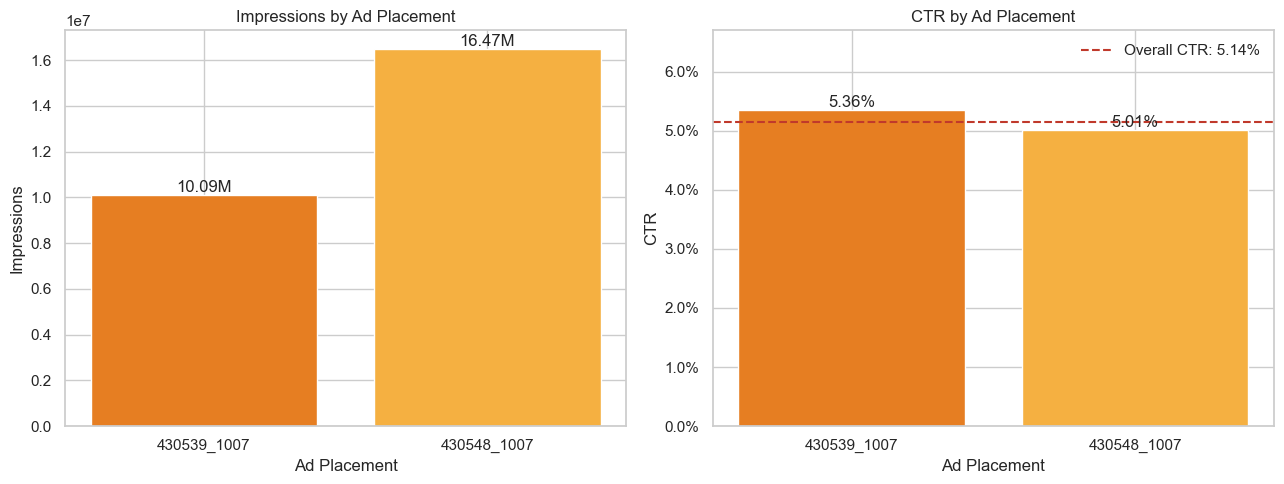

In [16]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

colors = ["#E67E22", "#F5B041"]

# 曝光量
axes[0].bar(
    channel_analysis["pid"],
    channel_analysis["impressions"],
    color=colors
)

axes[0].set_title("Impressions by Ad Placement")
axes[0].set_xlabel("Ad Placement")
axes[0].set_ylabel("Impressions")

for index, value in enumerate(
    channel_analysis["impressions"]
):
    axes[0].text(
        index,
        value,
        f"{value / 1_000_000:.2f}M",
        ha="center",
        va="bottom"
    )

# CTR
axes[1].bar(
    channel_analysis["pid"],
    channel_analysis["ctr"],
    color=colors
)

axes[1].axhline(
    overall_ctr,
    color="#C0392B",
    linestyle="--",
    label=f"Overall CTR: {overall_ctr:.2%}"
)

axes[1].set_title("CTR by Ad Placement")
axes[1].set_xlabel("Ad Placement")
axes[1].set_ylabel("CTR")
axes[1].set_ylim(
    0,
    channel_analysis["ctr"].max() * 1.25
)

axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, position: f"{value:.1%}")
)

for index, value in enumerate(channel_analysis["ctr"]):
    axes[1].text(
        index,
        value,
        f"{value:.2%}",
        ha="center",
        va="bottom"
    )

axes[1].legend()

plt.tight_layout()
plt.show()

In [17]:
date_analysis = (
    analysis_tables["date"]
    .copy()
    .sort_values("date")
    .reset_index(drop=True)
)

date_analysis["date"] = pd.to_datetime(
    date_analysis["date"]
)

display(
    date_analysis.style.format({
        "impressions": "{:,.0f}",
        "clicks": "{:,.0f}",
        "ctr": "{:.4%}",
        "lift_vs_overall": "{:+.2%}"
    })
)

,date,impressions,clicks,ctr,lift_vs_overall
0,2017-05-06 00:00:00,"3,270,348","170,332",5.2084%,+1.26%
1,2017-05-07 00:00:00,"3,430,002","175,780",5.1248%,-0.37%
2,2017-05-08 00:00:00,"3,354,523","174,394",5.1988%,+1.07%
3,2017-05-09 00:00:00,"3,248,016","169,606",5.2218%,+1.52%
4,2017-05-10 00:00:00,"3,333,752","172,190",5.1651%,+0.42%
5,2017-05-11 00:00:00,"3,378,604","177,827",5.2633%,+2.33%
6,2017-05-12 00:00:00,"3,234,051","159,437",4.9299%,-4.16%
7,2017-05-13 00:00:00,"3,308,665","166,490",5.0319%,-2.17%


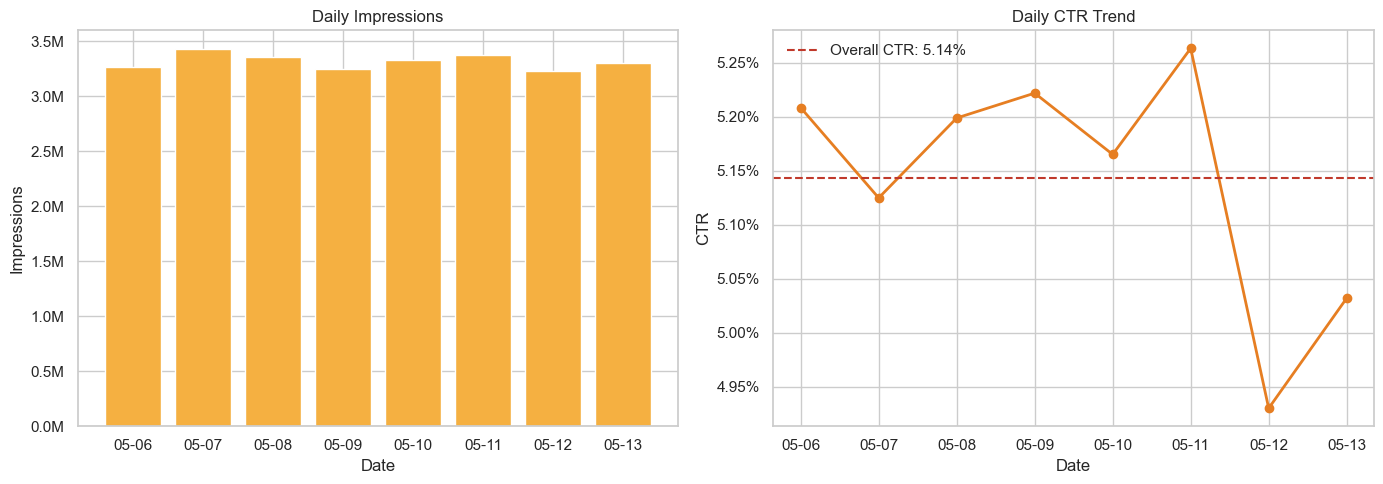

In [18]:
date_labels = (
    date_analysis["date"]
    .dt.strftime("%m-%d")
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# 每日曝光量
axes[0].bar(
    date_labels,
    date_analysis["impressions"],
    color="#F5B041"
)

axes[0].set_title("Daily Impressions")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Impressions")

axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, position: f"{value / 1_000_000:.1f}M"
    )
)

# 每日CTR
axes[1].plot(
    date_labels,
    date_analysis["ctr"],
    marker="o",
    linewidth=2,
    color="#E67E22"
)

axes[1].axhline(
    overall_ctr,
    color="#C0392B",
    linestyle="--",
    label=f"Overall CTR: {overall_ctr:.2%}"
)

axes[1].set_title("Daily CTR Trend")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("CTR")

axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, position: f"{value:.2%}"
    )
)

axes[1].legend()

plt.tight_layout()
plt.show()

In [19]:
weekday_analysis = (
    analysis_tables["weekday"]
    .copy()
    .sort_values("weekday")
    .reset_index(drop=True)
)

weekday_label_mapping = {
    0: "Mon",
    1: "Tue",
    2: "Wed",
    3: "Thu",
    4: "Fri",
    5: "Sat",
    6: "Sun"
}

weekday_analysis["weekday_label"] = (
    weekday_analysis["weekday"]
    .map(weekday_label_mapping)
)

# 计算每个星期几在数据中出现了几天
date_analysis["weekday"] = (
    date_analysis["date"].dt.weekday
)

weekday_day_counts = (
    date_analysis.groupby("weekday")
    .size()
)

weekday_analysis["days_observed"] = (
    weekday_analysis["weekday"]
    .map(weekday_day_counts)
)

weekday_analysis["avg_daily_impressions"] = (
    weekday_analysis["impressions"] /
    weekday_analysis["days_observed"]
)

hour_analysis = (
    analysis_tables["hour"]
    .copy()
    .sort_values("hour")
    .reset_index(drop=True)
)

display(
    weekday_analysis.style.format({
        "impressions": "{:,.0f}",
        "clicks": "{:,.0f}",
        "ctr": "{:.4%}",
        "lift_vs_overall": "{:+.2%}",
        "avg_daily_impressions": "{:,.0f}"
    })
)

display(
    hour_analysis.style.format({
        "impressions": "{:,.0f}",
        "clicks": "{:,.0f}",
        "ctr": "{:.4%}",
        "lift_vs_overall": "{:+.2%}"
    })
)

,weekday,impressions,clicks,ctr,lift_vs_overall,weekday_label,days_observed,avg_daily_impressions
0,0,"3,354,523","174,394",5.1988%,+1.07%,Mon,1,"3,354,523"
1,1,"3,248,016","169,606",5.2218%,+1.52%,Tue,1,"3,248,016"
2,2,"3,333,752","172,190",5.1651%,+0.42%,Wed,1,"3,333,752"
3,3,"3,378,604","177,827",5.2633%,+2.33%,Thu,1,"3,378,604"
4,4,"3,234,051","159,437",4.9299%,-4.16%,Fri,1,"3,234,051"
5,5,"6,579,013","336,822",5.1196%,-0.47%,Sat,2,"3,289,506"
6,6,"3,430,002","175,780",5.1248%,-0.37%,Sun,1,"3,430,002"


,hour,impressions,clicks,ctr,lift_vs_overall
0,0,"795,508","41,115",5.1684%,+0.48%
1,1,"392,951","20,031",5.0976%,-0.90%
2,2,"212,610","10,651",5.0096%,-2.61%
3,3,"142,652","7,233",5.0704%,-1.42%
4,4,"134,618","6,866",5.1004%,-0.84%
5,5,"271,644","13,386",4.9278%,-4.20%
6,6,"637,760","30,952",4.8532%,-5.65%
7,7,"873,453","41,625",4.7656%,-7.35%
8,8,"1,041,462","52,777",5.0676%,-1.48%
9,9,"1,231,945","64,272",5.2171%,+1.43%


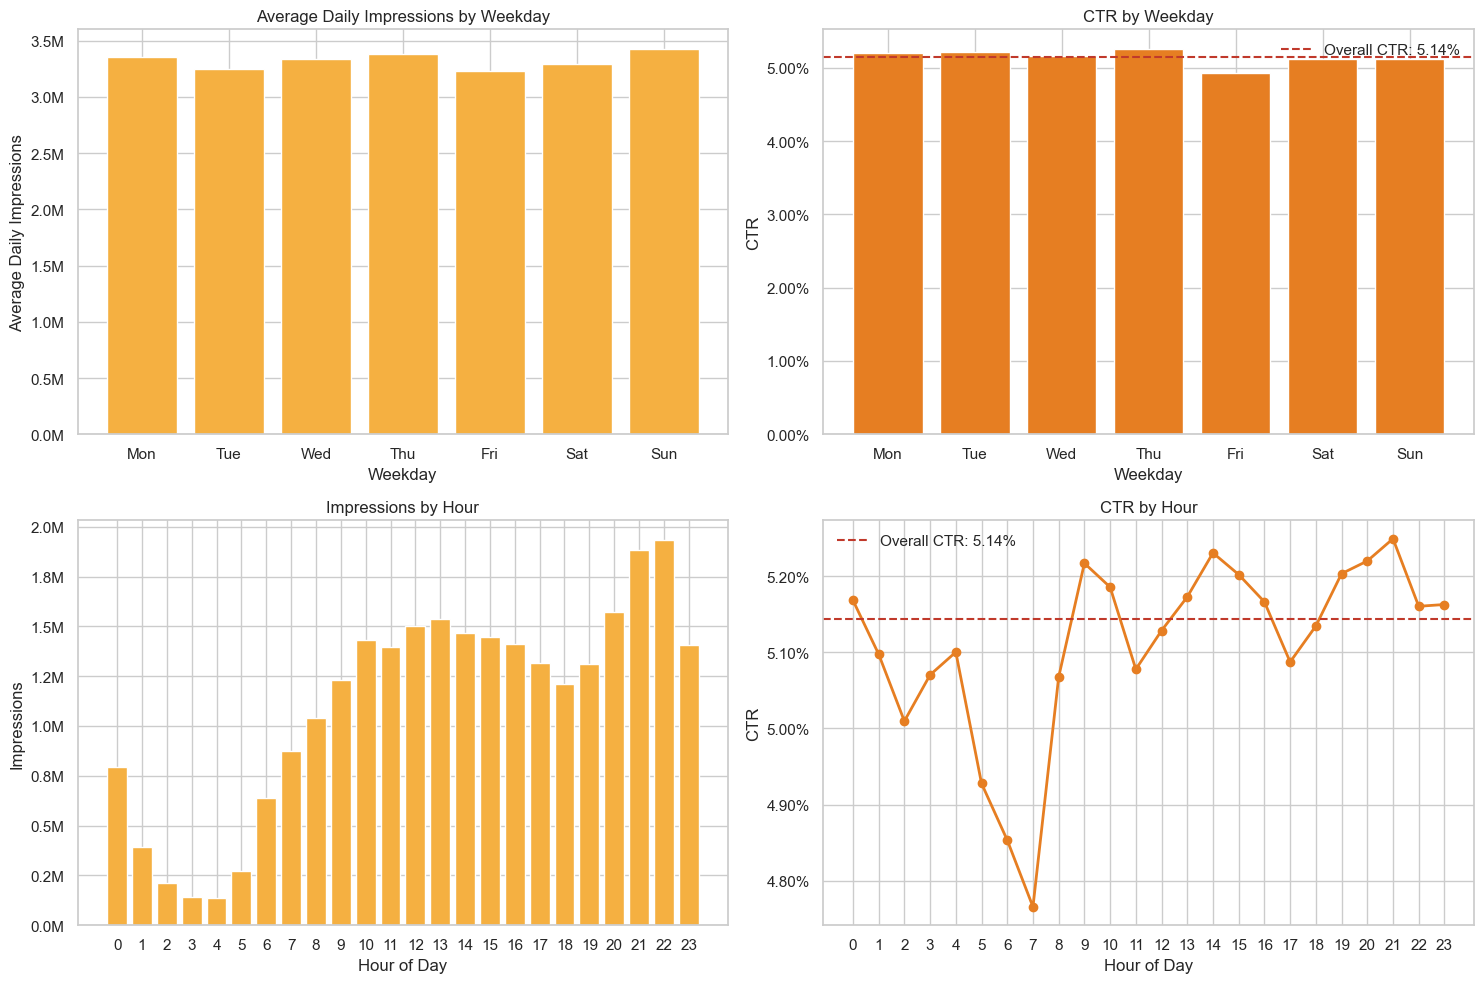

In [20]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10)
)

# 星期平均每日曝光量
axes[0, 0].bar(
    weekday_analysis["weekday_label"],
    weekday_analysis["avg_daily_impressions"],
    color="#F5B041"
)

axes[0, 0].set_title("Average Daily Impressions by Weekday")
axes[0, 0].set_xlabel("Weekday")
axes[0, 0].set_ylabel("Average Daily Impressions")

axes[0, 0].yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, position: f"{value / 1_000_000:.1f}M"
    )
)

# 星期CTR
axes[0, 1].bar(
    weekday_analysis["weekday_label"],
    weekday_analysis["ctr"],
    color="#E67E22"
)

axes[0, 1].axhline(
    overall_ctr,
    color="#C0392B",
    linestyle="--",
    label=f"Overall CTR: {overall_ctr:.2%}"
)

axes[0, 1].set_title("CTR by Weekday")
axes[0, 1].set_xlabel("Weekday")
axes[0, 1].set_ylabel("CTR")

axes[0, 1].yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, position: f"{value:.2%}"
    )
)

axes[0, 1].legend(loc="upper right")

# 小时曝光量
axes[1, 0].bar(
    hour_analysis["hour"],
    hour_analysis["impressions"],
    color="#F5B041"
)

axes[1, 0].set_title("Impressions by Hour")
axes[1, 0].set_xlabel("Hour of Day")
axes[1, 0].set_ylabel("Impressions")
axes[1, 0].set_xticks(range(24))

axes[1, 0].yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, position: f"{value / 1_000_000:.1f}M"
    )
)

# 小时CTR
axes[1, 1].plot(
    hour_analysis["hour"],
    hour_analysis["ctr"],
    marker="o",
    color="#E67E22",
    linewidth=2
)

axes[1, 1].axhline(
    overall_ctr,
    color="#C0392B",
    linestyle="--",
    label=f"Overall CTR: {overall_ctr:.2%}"
)

axes[1, 1].set_title("CTR by Hour")
axes[1, 1].set_xlabel("Hour of Day")
axes[1, 1].set_ylabel("CTR")
axes[1, 1].set_xticks(range(24))

axes[1, 1].yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, position: f"{value:.2%}"
    )
)

axes[1, 1].legend()

plt.tight_layout()
plt.show()

### 3.2 用户画像分析

本部分从性别、年龄层级、消费能力、购物深度、职业和新用户等级等维度比较用户CTR。

未匹配到用户画像的曝光记录被单独标记为未知类别，而不是直接删除，以便观察画像缺失情况并保留整体数据规模。

In [21]:
matched_user_ctr = (
    analysis_tables["user_profile_matched"]
    .loc[
        analysis_tables["user_profile_matched"][
            "user_profile_matched"
        ] == 1,
        "ctr"
    ]
    .iloc[0]
)

gender_analysis = (
    analysis_tables["final_gender_code"]
    .copy()
    .sort_values("final_gender_code")
    .reset_index(drop=True)
)

gender_mapping = {
    -1: "Unmatched",
    1: "Male",
    2: "Female"
}

gender_analysis["gender_label"] = (
    gender_analysis["final_gender_code"]
    .map(gender_mapping)
)

gender_analysis["lift_vs_matched_users"] = (
    gender_analysis["ctr"] /
    matched_user_ctr - 1
)

age_analysis = (
    analysis_tables["age_level"]
    .copy()
    .sort_values("age_level")
    .reset_index(drop=True)
)

age_analysis["age_label"] = (
    age_analysis["age_level"]
    .apply(
        lambda value:
        "Unmatched"
        if value == -1
        else f"Level {value}"
    )
)

age_analysis["lift_vs_matched_users"] = (
    age_analysis["ctr"] /
    matched_user_ctr - 1
)

display(
    gender_analysis.style.format({
        "impressions": "{:,.0f}",
        "clicks": "{:,.0f}",
        "ctr": "{:.4%}",
        "lift_vs_overall": "{:+.2%}",
        "lift_vs_matched_users": "{:+.2%}"
    })
)

display(
    age_analysis.style.format({
        "impressions": "{:,.0f}",
        "clicks": "{:,.0f}",
        "ctr": "{:.4%}",
        "lift_vs_overall": "{:+.2%}",
        "lift_vs_matched_users": "{:+.2%}"
    })
)

,final_gender_code,impressions,clicks,ctr,lift_vs_overall,gender_label,lift_vs_matched_users
0,-1,"1,528,526","81,543",5.3347%,+3.71%,Unmatched,+3.95%
1,1,"6,880,966","332,724",4.8354%,-5.99%,Male,-5.78%
2,2,"18,148,469","951,789",5.2445%,+1.96%,Female,+2.19%


,age_level,impressions,clicks,ctr,lift_vs_overall,age_label,lift_vs_matched_users
0,-1,"1,528,526","81,543",5.3347%,+3.71%,Unmatched,+3.95%
1,0,"9,189",482,5.2454%,+1.98%,Level 0,+2.21%
2,1,"1,379,703","76,211",5.5237%,+7.39%,Level 1,+7.63%
3,2,"4,567,837","236,328",5.1737%,+0.58%,Level 2,+0.81%
4,3,"7,573,614","386,683",5.1057%,-0.74%,Level 3,-0.51%
5,4,"6,406,045","317,358",4.9540%,-3.69%,Level 4,-3.47%
6,5,"4,652,618","242,691",5.2162%,+1.41%,Level 5,+1.64%
7,6,"440,429","24,760",5.6218%,+9.30%,Level 6,+9.54%


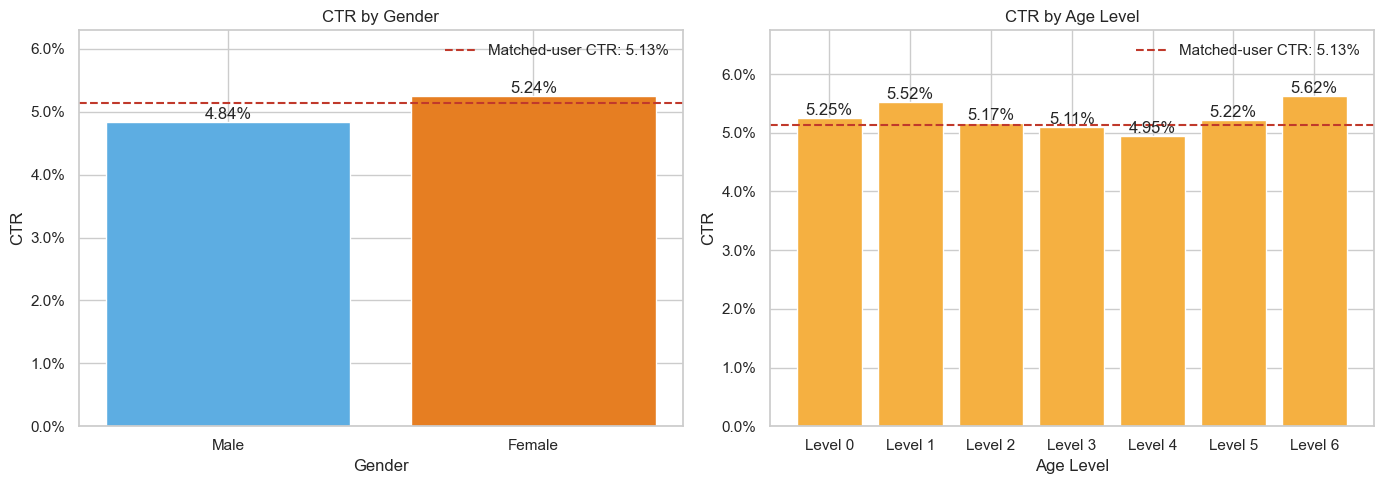

In [22]:
gender_plot = gender_analysis[
    gender_analysis["final_gender_code"] != -1
].copy()

age_plot = age_analysis[
    age_analysis["age_level"] != -1
].copy()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

axes[0].bar(
    gender_plot["gender_label"],
    gender_plot["ctr"],
    color=["#5DADE2", "#E67E22"]
)

axes[0].axhline(
    matched_user_ctr,
    color="#C0392B",
    linestyle="--",
    label=f"Matched-user CTR: {matched_user_ctr:.2%}"
)

axes[0].set_title("CTR by Gender")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("CTR")
axes[0].set_ylim(0, gender_plot["ctr"].max() * 1.2)

axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, position: f"{value:.1%}"
    )
)

for index, value in enumerate(gender_plot["ctr"]):
    axes[0].text(
        index,
        value,
        f"{value:.2%}",
        ha="center",
        va="bottom"
    )

axes[0].legend()

axes[1].bar(
    age_plot["age_label"],
    age_plot["ctr"],
    color="#F5B041"
)

axes[1].axhline(
    matched_user_ctr,
    color="#C0392B",
    linestyle="--",
    label=f"Matched-user CTR: {matched_user_ctr:.2%}"
)

axes[1].set_title("CTR by Age Level")
axes[1].set_xlabel("Age Level")
axes[1].set_ylabel("CTR")
axes[1].set_ylim(0, age_plot["ctr"].max() * 1.2)

axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, position: f"{value:.1%}"
    )
)

for index, value in enumerate(age_plot["ctr"]):
    axes[1].text(
        index,
        value,
        f"{value:.2%}",
        ha="center",
        va="bottom"
    )

axes[1].legend()

plt.tight_layout()
plt.show()

In [23]:
def prepare_user_dimension(
    table_name,
    feature_column,
    label_mapping,
    label_column
):
    result = (
        analysis_tables[table_name]
        .copy()
        .sort_values(feature_column)
        .reset_index(drop=True)
    )

    result[label_column] = (
        result[feature_column].map(label_mapping)
    )

    result["lift_vs_matched_users"] = (
        result["ctr"] / matched_user_ctr - 1
    )

    return result

In [24]:
pvalue_analysis = prepare_user_dimension(
    table_name="pvalue_level",
    feature_column="pvalue_level",
    label_mapping={
        -1: "Unknown",
        1: "Level 1",
        2: "Level 2",
        3: "Level 3"
    },
    label_column="pvalue_label"
)

shopping_analysis = prepare_user_dimension(
    table_name="shopping_level",
    feature_column="shopping_level",
    label_mapping={
        -1: "Unmatched",
        1: "Level 1",
        2: "Level 2",
        3: "Level 3"
    },
    label_column="shopping_label"
)

occupation_analysis = prepare_user_dimension(
    table_name="occupation",
    feature_column="occupation",
    label_mapping={
        -1: "Unmatched",
        0: "Non-student",
        1: "College student"
    },
    label_column="occupation_label"
)

new_user_analysis = prepare_user_dimension(
    table_name="new_user_class_level",
    feature_column="new_user_class_level",
    label_mapping={
        -1: "Unknown",
        1: "Level 1",
        2: "Level 2",
        3: "Level 3",
        4: "Level 4"
    },
    label_column="new_user_label"
)

In [25]:
format_columns = {
    "impressions": "{:,.0f}",
    "clicks": "{:,.0f}",
    "ctr": "{:.4%}",
    "lift_vs_overall": "{:+.2%}",
    "lift_vs_matched_users": "{:+.2%}"
}

display(pvalue_analysis.style.format(format_columns))
display(shopping_analysis.style.format(format_columns))
display(occupation_analysis.style.format(format_columns))
display(new_user_analysis.style.format(format_columns))

,pvalue_level,impressions,clicks,ctr,lift_vs_overall,pvalue_label,lift_vs_matched_users
0,-1,"14,552,798","752,759",5.1726%,+0.56%,Unknown,+0.79%
1,1,"4,117,894","211,887",5.1455%,+0.04%,Level 1,+0.26%
2,2,"6,991,303","359,133",5.1369%,-0.13%,Level 2,+0.09%
3,3,"895,966","42,277",4.7186%,-8.26%,Level 3,-8.06%


,shopping_level,impressions,clicks,ctr,lift_vs_overall,shopping_label,lift_vs_matched_users
0,-1,"1,528,526","81,543",5.3347%,+3.71%,Unmatched,+3.95%
1,1,"1,118,722","60,388",5.3979%,+4.94%,Level 1,+5.18%
2,2,"2,594,215","134,194",5.1728%,+0.57%,Level 2,+0.80%
3,3,"21,316,498","1,089,931",5.1131%,-0.59%,Level 3,-0.37%


,occupation,impressions,clicks,ctr,lift_vs_overall,occupation_label,lift_vs_matched_users
0,-1,"1,528,526","81,543",5.3347%,+3.71%,Unmatched,+3.95%
1,0,"23,665,487","1,214,241",5.1309%,-0.25%,Non-student,-0.02%
2,1,"1,363,948","70,272",5.1521%,+0.16%,College student,+0.39%


,new_user_class_level,impressions,clicks,ctr,lift_vs_overall,new_user_label,lift_vs_matched_users
0,-1,"8,224,829","432,423",5.2575%,+2.21%,Unknown,+2.45%
1,1,"1,881,278","94,867",5.0427%,-1.96%,Level 1,-1.74%
2,2,"8,125,425","415,627",5.1151%,-0.55%,Level 2,-0.33%
3,3,"4,620,080","233,785",5.0602%,-1.62%,Level 3,-1.40%
4,4,"3,706,349","189,354",5.1089%,-0.68%,Level 4,-0.45%


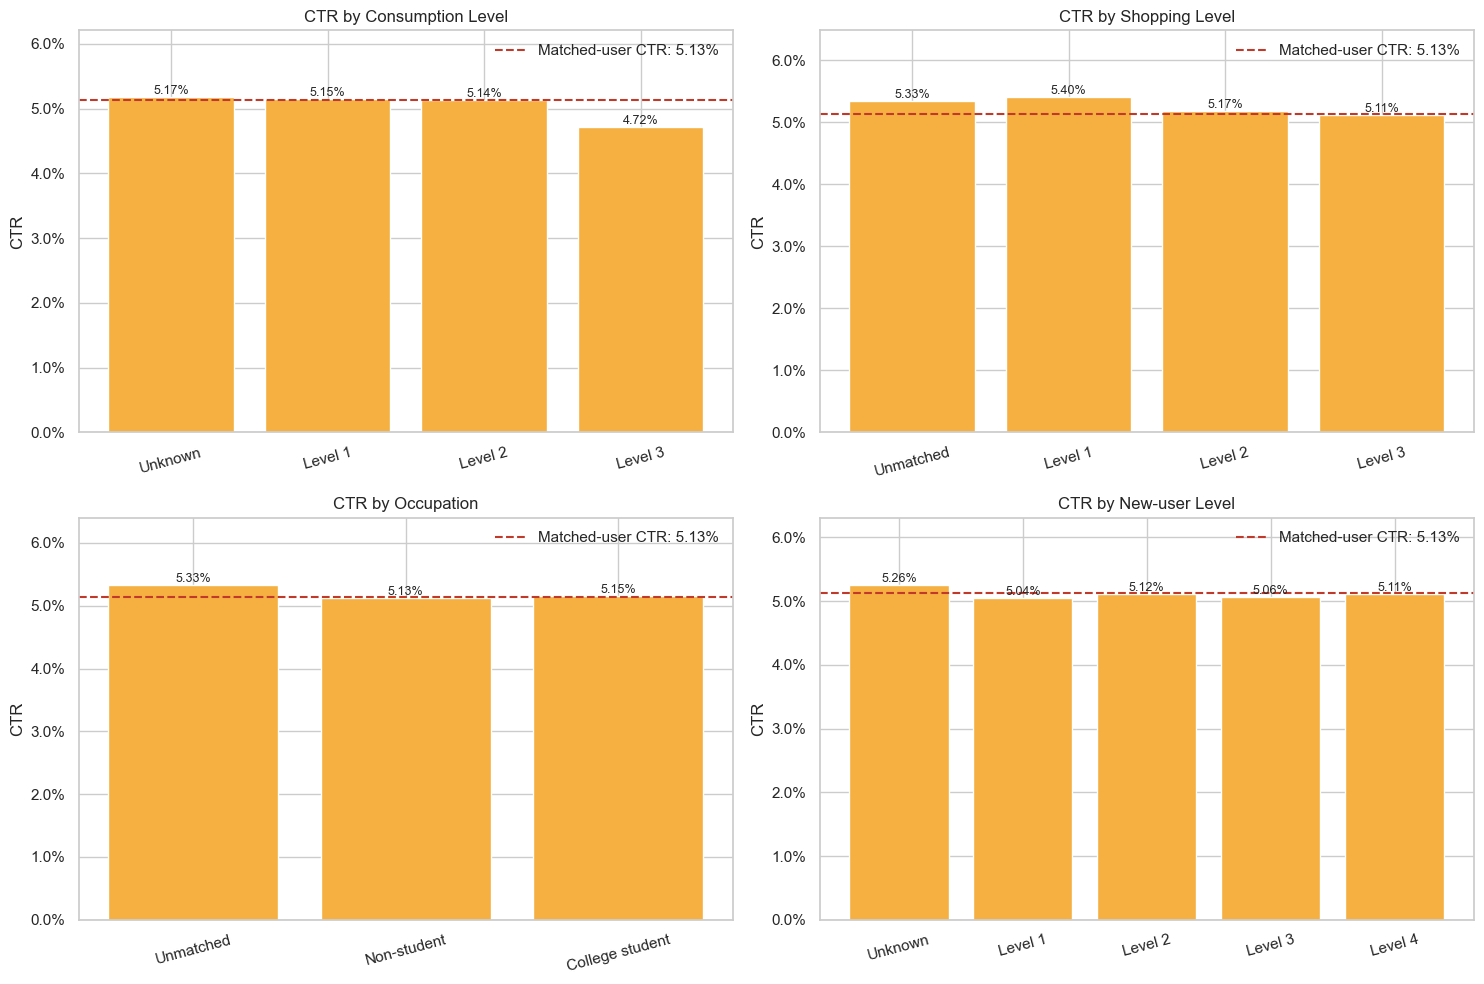

In [26]:
plot_settings = [
    (
        pvalue_analysis,
        "pvalue_label",
        "CTR by Consumption Level"
    ),
    (
        shopping_analysis,
        "shopping_label",
        "CTR by Shopping Level"
    ),
    (
        occupation_analysis,
        "occupation_label",
        "CTR by Occupation"
    ),
    (
        new_user_analysis,
        "new_user_label",
        "CTR by New-user Level"
    )
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10)
)

for ax, (
    plot_data,
    label_column,
    title
) in zip(axes.flatten(), plot_settings):

    ax.bar(
        plot_data[label_column],
        plot_data["ctr"],
        color="#F5B041"
    )

    ax.axhline(
        matched_user_ctr,
        color="#C0392B",
        linestyle="--",
        label=f"Matched-user CTR: {matched_user_ctr:.2%}"
    )

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("CTR")

    ax.set_ylim(
        0,
        plot_data["ctr"].max() * 1.2
    )

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(
            lambda value, position: f"{value:.1%}"
        )
    )

    ax.tick_params(
        axis="x",
        rotation=15
    )

    for index, value in enumerate(plot_data["ctr"]):
        ax.text(
            index,
            value,
            f"{value:.2%}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    ax.legend()

plt.tight_layout()
plt.show()

### 3.3 商品特征与品类分析

本部分分析不同商品价格区间、品牌信息完整性和商品品类的点击表现。

由于商品品类数量较多，直接按照CTR排名容易受到小样本波动影响。因此，品类排行榜仅保留至少20,000次曝光的品类，并结合曝光量、曝光占比和CTR共同判断其业务价值。

In [27]:
price_analysis = (
    analysis_tables["price_bin"]
    .copy()
)

price_order = [
    "50元以下",
    "50-149元",
    "150-499元",
    "500-1999元",
    "2000-9999元",
    "10000元及以上"
]

price_label_mapping = {
    "50元以下": "Under 50",
    "50-149元": "50-149",
    "150-499元": "150-499",
    "500-1999元": "500-1,999",
    "2000-9999元": "2,000-9,999",
    "10000元及以上": "10,000+"
}

price_analysis["price_bin"] = pd.Categorical(
    price_analysis["price_bin"],
    categories=price_order,
    ordered=True
)

price_analysis = (
    price_analysis
    .sort_values("price_bin")
    .reset_index(drop=True)
)

price_analysis["price_label"] = (
    price_analysis["price_bin"]
    .map(price_label_mapping)
)

price_analysis["impression_share"] = (
    price_analysis["impressions"] /
    price_analysis["impressions"].sum()
)

brand_info_analysis = (
    analysis_tables["brand_missing"]
    .copy()
    .sort_values("brand_missing")
    .reset_index(drop=True)
)

brand_info_analysis["brand_label"] = (
    brand_info_analysis["brand_missing"]
    .map({
        0: "Brand available",
        1: "Brand missing"
    })
)

brand_info_analysis["impression_share"] = (
    brand_info_analysis["impressions"] /
    brand_info_analysis["impressions"].sum()
)

In [28]:
display(
    price_analysis.style.format({
        "impressions": "{:,.0f}",
        "clicks": "{:,.0f}",
        "ctr": "{:.4%}",
        "lift_vs_overall": "{:+.2%}",
        "impression_share": "{:.2%}"
    })
)

display(
    brand_info_analysis.style.format({
        "impressions": "{:,.0f}",
        "clicks": "{:,.0f}",
        "ctr": "{:.4%}",
        "lift_vs_overall": "{:+.2%}",
        "impression_share": "{:.2%}"
    })
)

,price_bin,impressions,clicks,ctr,lift_vs_overall,price_label,impression_share
0,50元以下,"4,067,665","242,786",5.9687%,+16.04%,Under 50,15.32%
1,50-149元,"8,149,776","421,364",5.1703%,+0.52%,50-149,30.69%
2,150-499元,"10,412,375","518,924",4.9837%,-3.11%,150-499,39.21%
3,500-1999元,"3,032,396","143,672",4.7379%,-7.89%,"500-1,999",11.42%
4,2000-9999元,"786,024","33,760",4.2950%,-16.50%,"2,000-9,999",2.96%
5,10000元及以上,"109,725","5,550",5.0581%,-1.66%,"10,000+",0.41%


,brand_missing,impressions,clicks,ctr,lift_vs_overall,brand_label,impression_share
0,0,"18,266,267","908,731",4.9749%,-3.28%,Brand available,68.78%
1,1,"8,291,694","457,325",5.5155%,+7.23%,Brand missing,31.22%


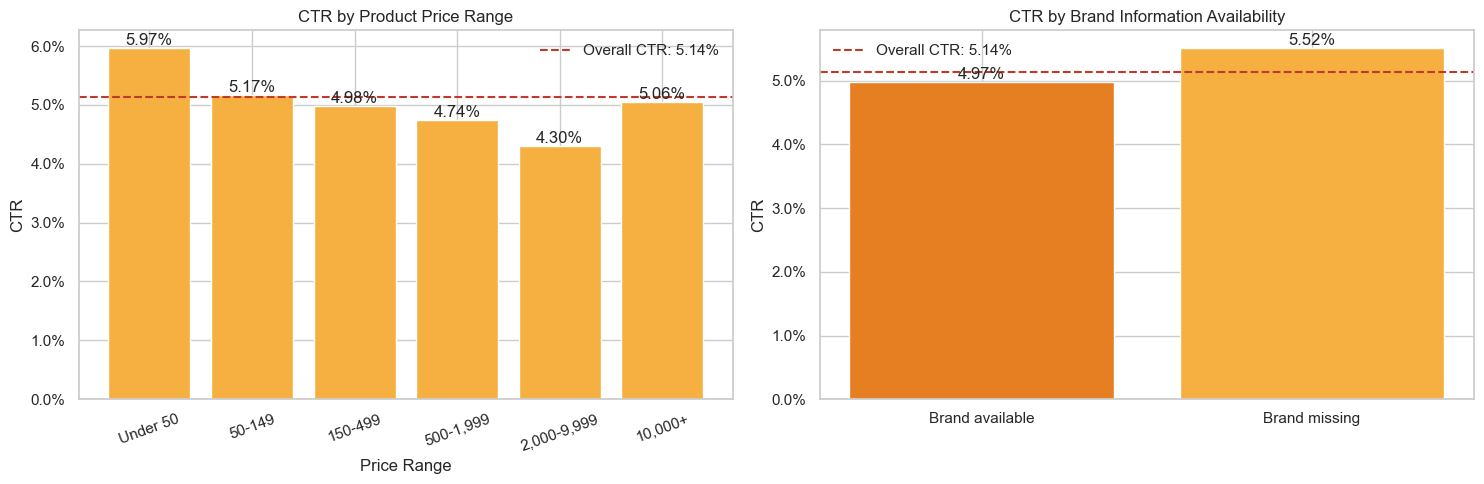

In [29]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)

axes[0].bar(
    price_analysis["price_label"],
    price_analysis["ctr"],
    color="#F5B041"
)

axes[0].axhline(
    overall_ctr,
    color="#C0392B",
    linestyle="--",
    label=f"Overall CTR: {overall_ctr:.2%}"
)

axes[0].set_title("CTR by Product Price Range")
axes[0].set_xlabel("Price Range")
axes[0].set_ylabel("CTR")
axes[0].tick_params(axis="x", rotation=20)

axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, position: f"{value:.1%}"
    )
)

for index, value in enumerate(price_analysis["ctr"]):
    axes[0].text(
        index,
        value,
        f"{value:.2%}",
        ha="center",
        va="bottom"
    )

axes[0].legend()

axes[1].bar(
    brand_info_analysis["brand_label"],
    brand_info_analysis["ctr"],
    color=["#E67E22", "#F5B041"]
)

axes[1].axhline(
    overall_ctr,
    color="#C0392B",
    linestyle="--",
    label=f"Overall CTR: {overall_ctr:.2%}"
)

axes[1].set_title("CTR by Brand Information Availability")
axes[1].set_xlabel("")
axes[1].set_ylabel("CTR")

axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, position: f"{value:.1%}"
    )
)

for index, value in enumerate(brand_info_analysis["ctr"]):
    axes[1].text(
        index,
        value,
        f"{value:.2%}",
        ha="center",
        va="bottom"
    )

axes[1].legend()

plt.tight_layout()
plt.show()

Total number of categories: 6,769
Categories with at least 20,000 impressions: 152

Top 10 eligible categories by CTR


,cate_id,impressions,clicks,ctr,lift_vs_overall,impression_share
0,2468,"30,608","2,575",8.4128%,+63.56%,0.12%
1,1157,"29,892","2,461",8.2330%,+60.06%,0.11%
2,4289,"23,354","1,903",8.1485%,+58.42%,0.09%
3,531,"21,306","1,651",7.7490%,+50.65%,0.08%
4,4287,"31,160","2,393",7.6797%,+49.30%,0.12%
5,4278,"71,346","5,156",7.2268%,+40.50%,0.27%
6,8111,"29,800","2,149",7.2114%,+40.20%,0.11%
7,877,"27,492","1,883",6.8493%,+33.16%,0.10%
8,7266,"33,944","2,271",6.6904%,+30.07%,0.13%
9,6407,"114,496","7,547",6.5915%,+28.15%,0.43%



Bottom 10 eligible categories by CTR


,cate_id,impressions,clicks,ctr,lift_vs_overall,impression_share
0,6281,"134,401","4,321",3.2150%,-37.50%,0.51%
1,2628,"56,879","1,977",3.4758%,-32.43%,0.21%
2,4505,"455,777","15,902",3.4890%,-32.17%,1.72%
3,9494,"70,959","2,495",3.5161%,-31.64%,0.27%
4,6412,"49,456","1,741",3.5203%,-31.56%,0.19%
5,10876,"23,275",827,3.5532%,-30.92%,0.09%
6,6342,"41,774","1,492",3.5716%,-30.56%,0.16%
7,5989,"23,695",849,3.5830%,-30.34%,0.09%
8,4285,"49,398","1,774",3.5912%,-30.18%,0.19%
9,4385,"331,271","11,939",3.6040%,-29.93%,1.25%


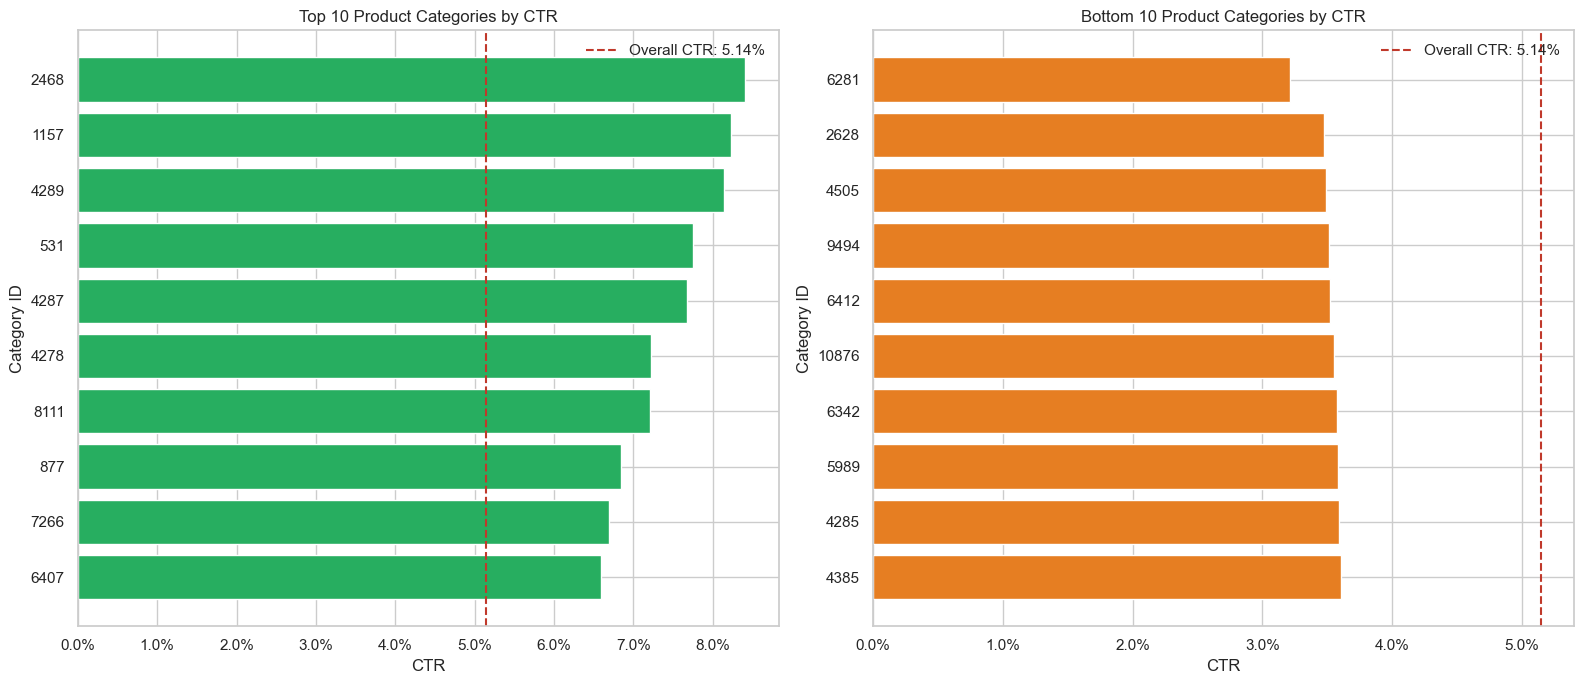

In [30]:
# Product category performance analysis

category_analysis = (
    analysis_tables["cate_id"]
    .copy()
    .dropna(subset=["cate_id"])
)

category_analysis["cate_id"] = (
    category_analysis["cate_id"]
    .astype("int64")
)

category_analysis["impression_share"] = (
    category_analysis["impressions"] /
    category_analysis["impressions"].sum()
)

# Minimum exposure threshold to reduce small-sample noise
min_category_impressions = 20_000

eligible_categories = (
    category_analysis[
        category_analysis["impressions"] >= min_category_impressions
    ]
    .copy()
)

top_categories = (
    eligible_categories
    .sort_values(
        ["ctr", "impressions"],
        ascending=[False, False]
    )
    .head(10)
    .reset_index(drop=True)
)

bottom_categories = (
    eligible_categories
    .sort_values(
        ["ctr", "impressions"],
        ascending=[True, False]
    )
    .head(10)
    .reset_index(drop=True)
)

print(
    f"Total number of categories: "
    f"{category_analysis['cate_id'].nunique():,}"
)

print(
    f"Categories with at least "
    f"{min_category_impressions:,} impressions: "
    f"{eligible_categories['cate_id'].nunique():,}"
)

print("\nTop 10 eligible categories by CTR")

display(
    top_categories[
        [
            "cate_id",
            "impressions",
            "clicks",
            "ctr",
            "lift_vs_overall",
            "impression_share"
        ]
    ].style.format({
        "impressions": "{:,.0f}",
        "clicks": "{:,.0f}",
        "ctr": "{:.4%}",
        "lift_vs_overall": "{:+.2%}",
        "impression_share": "{:.2%}"
    })
)

print("\nBottom 10 eligible categories by CTR")

display(
    bottom_categories[
        [
            "cate_id",
            "impressions",
            "clicks",
            "ctr",
            "lift_vs_overall",
            "impression_share"
        ]
    ].style.format({
        "impressions": "{:,.0f}",
        "clicks": "{:,.0f}",
        "ctr": "{:.4%}",
        "lift_vs_overall": "{:+.2%}",
        "impression_share": "{:.2%}"
    })
)

# Visualization
top_plot = top_categories.sort_values("ctr")
bottom_plot = bottom_categories.sort_values("ctr", ascending=False)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 7)
)

axes[0].barh(
    top_plot["cate_id"].astype(str),
    top_plot["ctr"],
    color="#27AE60"
)

axes[0].axvline(
    overall_ctr,
    color="#C0392B",
    linestyle="--",
    label=f"Overall CTR: {overall_ctr:.2%}"
)

axes[0].set_title("Top 10 Product Categories by CTR")
axes[0].set_xlabel("CTR")
axes[0].set_ylabel("Category ID")
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, position: f"{value:.1%}"
    )
)
axes[0].legend()

axes[1].barh(
    bottom_plot["cate_id"].astype(str),
    bottom_plot["ctr"],
    color="#E67E22"
)

axes[1].axvline(
    overall_ctr,
    color="#C0392B",
    linestyle="--",
    label=f"Overall CTR: {overall_ctr:.2%}"
)

axes[1].set_title("Bottom 10 Product Categories by CTR")
axes[1].set_xlabel("CTR")
axes[1].set_ylabel("Category ID")
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, position: f"{value:.1%}"
    )
)
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. 统计检验

本部分使用双样本比例Z检验和95%置信区间，验证渠道、性别、职业和品牌信息组之间的CTR差异是否具有统计意义。

由于本项目包含超过2,600万次曝光，较小的差异也可能达到统计显著。因此，分析不只关注p值，还同时报告CTR百分点差异、相对提升幅度和置信区间，以判断差异是否具有实际业务价值。

,comparison,group_a,group_b,ctr_a,ctr_b,difference_pp,ci_lower_pp,ci_upper_pp,relative_lift,z_statistic,p_value
0,Channel,430539_1007,430548_1007,5.3578%,5.0126%,+0.3453,+0.3278,+0.3627,+6.89%,39.10,<1e-300
1,Gender,Female,Male,5.2445%,4.8354%,+0.4090,+0.3900,+0.4281,+8.46%,41.41,<1e-300
2,Occupation,College student,Non-student,5.1521%,5.1309%,+0.0213,-0.0169,+0.0594,+0.41%,1.09,0.2741
3,Brand information,Brand ID missing,Brand ID available,5.5155%,4.9749%,+0.5405,+0.5221,+0.5590,+10.87%,58.44,<1e-300


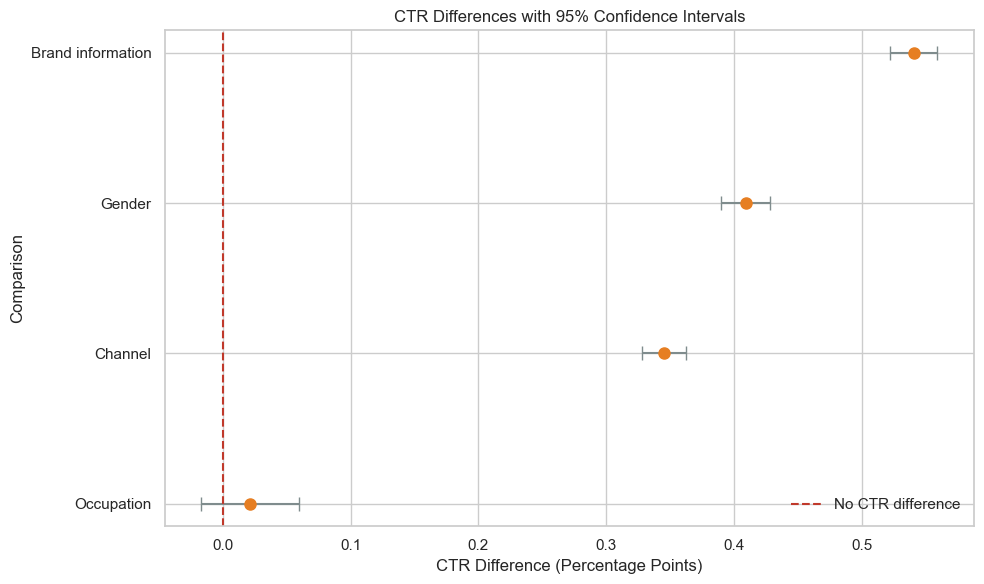

In [31]:
from scipy.stats import norm

def two_proportion_test(
    table,
    group_column,
    group_a,
    group_b,
    label_a,
    label_b,
    comparison_name
):
    row_a = table.loc[
        table[group_column] == group_a
    ].iloc[0]

    row_b = table.loc[
        table[group_column] == group_b
    ].iloc[0]

    clicks_a = int(row_a["clicks"])
    impressions_a = int(row_a["impressions"])

    clicks_b = int(row_b["clicks"])
    impressions_b = int(row_b["impressions"])

    ctr_a = clicks_a / impressions_a
    ctr_b = clicks_b / impressions_b

    ctr_difference = ctr_a - ctr_b

    pooled_ctr = (
        (clicks_a + clicks_b) /
        (impressions_a + impressions_b)
    )

    pooled_standard_error = np.sqrt(
        pooled_ctr *
        (1 - pooled_ctr) *
        (
            1 / impressions_a +
            1 / impressions_b
        )
    )

    z_statistic = (
        ctr_difference /
        pooled_standard_error
    )

    p_value = (
        2 *
        norm.sf(abs(z_statistic))
    )

    difference_standard_error = np.sqrt(
        ctr_a * (1 - ctr_a) / impressions_a +
        ctr_b * (1 - ctr_b) / impressions_b
    )

    confidence_lower = (
        ctr_difference -
        1.96 * difference_standard_error
    )

    confidence_upper = (
        ctr_difference +
        1.96 * difference_standard_error
    )

    return {
        "comparison": comparison_name,
        "group_a": label_a,
        "group_b": label_b,
        "ctr_a": ctr_a,
        "ctr_b": ctr_b,
        "difference_pp": ctr_difference * 100,
        "ci_lower_pp": confidence_lower * 100,
        "ci_upper_pp": confidence_upper * 100,
        "relative_lift": ctr_a / ctr_b - 1,
        "z_statistic": z_statistic,
        "p_value": p_value
    }


test_results = pd.DataFrame([
    two_proportion_test(
        table=channel_analysis,
        group_column="pid",
        group_a="430539_1007",
        group_b="430548_1007",
        label_a="430539_1007",
        label_b="430548_1007",
        comparison_name="Channel"
    ),

    two_proportion_test(
        table=gender_analysis,
        group_column="final_gender_code",
        group_a=2,
        group_b=1,
        label_a="Female",
        label_b="Male",
        comparison_name="Gender"
    ),

    two_proportion_test(
        table=occupation_analysis,
        group_column="occupation",
        group_a=1,
        group_b=0,
        label_a="College student",
        label_b="Non-student",
        comparison_name="Occupation"
    ),

    two_proportion_test(
        table=brand_info_analysis,
        group_column="brand_missing",
        group_a=1,
        group_b=0,
        label_a="Brand ID missing",
        label_b="Brand ID available",
        comparison_name="Brand information"
    )
])

def format_p_value(value):
    if value == 0:
        return "<1e-300"

    if value < 0.001:
        return f"{value:.2e}"

    return f"{value:.4f}"

display(
    test_results.style.format({
        "ctr_a": "{:.4%}",
        "ctr_b": "{:.4%}",
        "difference_pp": "{:+.4f}",
        "ci_lower_pp": "{:+.4f}",
        "ci_upper_pp": "{:+.4f}",
        "relative_lift": "{:+.2%}",
        "z_statistic": "{:.2f}",
        "p_value": format_p_value
    })
)

# Confidence interval visualization
plot_results = (
    test_results
    .sort_values("difference_pp")
    .reset_index(drop=True)
)

lower_error = (
    plot_results["difference_pp"] -
    plot_results["ci_lower_pp"]
)

upper_error = (
    plot_results["ci_upper_pp"] -
    plot_results["difference_pp"]
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(
    plot_results["difference_pp"],
    plot_results["comparison"],
    xerr=[
        lower_error,
        upper_error
    ],
    fmt="o",
    color="#E67E22",
    ecolor="#7F8C8D",
    capsize=5,
    markersize=8
)

ax.axvline(
    0,
    color="#C0392B",
    linestyle="--",
    label="No CTR difference"
)

ax.set_title(
    "CTR Differences with 95% Confidence Intervals"
)

ax.set_xlabel(
    "CTR Difference (Percentage Points)"
)

ax.set_ylabel("Comparison")
ax.legend()

plt.tight_layout()
plt.show()

## 5. 多维交叉分析

单维分析可能受到用户结构、商品价格和投放时段差异的共同影响。本部分进一步分析“渠道 × 小时”和“性别 × 价格区间”的CTR表现。

渠道与小时交叉分析用于寻找不同渠道各自适合的投放时段；性别与价格交叉分析用于检验低价商品的CTR优势是否在男性和女性用户中都成立。

In [32]:
# Multidimensional cross analysis:
# 1. Channel × Hour
# 2. Gender × Price Range

channel_hour_metrics = None
gender_price_metrics = None

gender_lookup = user_clean[
    [
        "user",
        "final_gender_code"
    ]
].copy()

price_lookup = ad_clean[
    [
        "adgroup_id",
        "price_bin"
    ]
].copy()


def aggregate_cross_metrics(
    data,
    group_columns
):
    return (
        data.groupby(
            group_columns,
            observed=True,
            dropna=False
        )["clk"]
        .agg(
            impressions="size",
            clicks="sum"
        )
    )


processed_cross_rows = 0

with tarfile.open(RAW_PATH, mode="r:gz") as tar:
    raw_member = next(
        member for member in tar.getmembers()
        if member.name.endswith("raw_sample.csv")
    )

    raw_file = tar.extractfile(raw_member)

    for chunk in pd.read_csv(
        raw_file,
        usecols=[
            "user",
            "time_stamp",
            "adgroup_id",
            "pid",
            "clk"
        ],
        chunksize=1_000_000
    ):
        # Beijing hour
        chunk["hour"] = (
            pd.to_datetime(
                chunk["time_stamp"],
                unit="s",
                utc=True
            )
            .dt
            .tz_convert("Asia/Shanghai")
            .dt
            .hour
            .astype("int8")
        )

        # Channel × Hour aggregation
        current_channel_hour = (
            aggregate_cross_metrics(
                chunk,
                ["pid", "hour"]
            )
        )

        if channel_hour_metrics is None:
            channel_hour_metrics = (
                current_channel_hour
            )
        else:
            channel_hour_metrics = (
                channel_hour_metrics
                .add(
                    current_channel_hour,
                    fill_value=0
                )
            )

        # Add gender and product price information
        cross_merged = (
            chunk[
                [
                    "user",
                    "adgroup_id",
                    "clk"
                ]
            ]
            .merge(
                gender_lookup,
                on="user",
                how="left",
                validate="many_to_one"
            )
            .merge(
                price_lookup,
                on="adgroup_id",
                how="left",
                validate="many_to_one"
            )
        )

        # Only compare known male and female users
        cross_merged = cross_merged[
            cross_merged["final_gender_code"].isin(
                [1, 2]
            )
            &
            cross_merged["price_bin"].notna()
        ].copy()

        cross_merged["price_bin"] = (
            cross_merged["price_bin"]
            .astype("object")
        )

        # Gender × Price aggregation
        current_gender_price = (
            aggregate_cross_metrics(
                cross_merged,
                [
                    "final_gender_code",
                    "price_bin"
                ]
            )
        )

        if gender_price_metrics is None:
            gender_price_metrics = (
                current_gender_price
            )
        else:
            gender_price_metrics = (
                gender_price_metrics
                .add(
                    current_gender_price,
                    fill_value=0
                )
            )

        processed_cross_rows += len(chunk)

        print(
            f"\rProcessed for cross analysis: "
            f"{processed_cross_rows:,} rows",
            end=""
        )

print("\nCross-dimensional aggregation completed.")

assert processed_cross_rows == total_rows

Processed for cross analysis: 26,557,961 rows
Cross-dimensional aggregation completed.


Top 3 hours for each channel


,pid,hour,impressions,clicks,ctr,channel_ctr,lift_vs_channel
0,430539_1007,4,"51,882","2,898",5.5858%,5.3578%,+4.25%
1,430539_1007,21,"669,417","36,812",5.4991%,5.3578%,+2.64%
2,430539_1007,0,"332,467","18,190",5.4712%,5.3578%,+2.12%
3,430548_1007,21,"1,212,493","61,975",5.1114%,5.0126%,+1.97%
4,430548_1007,14,"904,611","46,140",5.1005%,5.0126%,+1.76%
5,430548_1007,20,"1,003,331","51,070",5.0900%,5.0126%,+1.55%


CTR by Gender and Product Price Range


,gender_label,price_bin,impressions,clicks,ctr,gender_ctr,lift_vs_gender
0,Female,50元以下,"2,713,655","163,167",6.0128%,5.2445%,+14.65%
1,Female,50-149元,"5,766,808","303,720",5.2667%,5.2445%,+0.42%
2,Female,150-499元,"7,237,043","370,064",5.1135%,5.2445%,-2.50%
3,Female,500-1999元,"1,949,838","94,092",4.8256%,5.2445%,-7.99%
4,Female,2000-9999元,"421,632","17,780",4.2169%,5.2445%,-19.59%
5,Female,10000元及以上,"59,493","2,966",4.9855%,5.2445%,-4.94%
6,Male,50元以下,"1,085,994","62,743",5.7775%,4.8354%,+19.48%
7,Male,50-149元,"1,903,618","92,213",4.8441%,4.8354%,+0.18%
8,Male,150-499元,"2,593,750","119,360",4.6018%,4.8354%,-4.83%
9,Male,500-1999元,"923,901","41,708",4.5143%,4.8354%,-6.64%


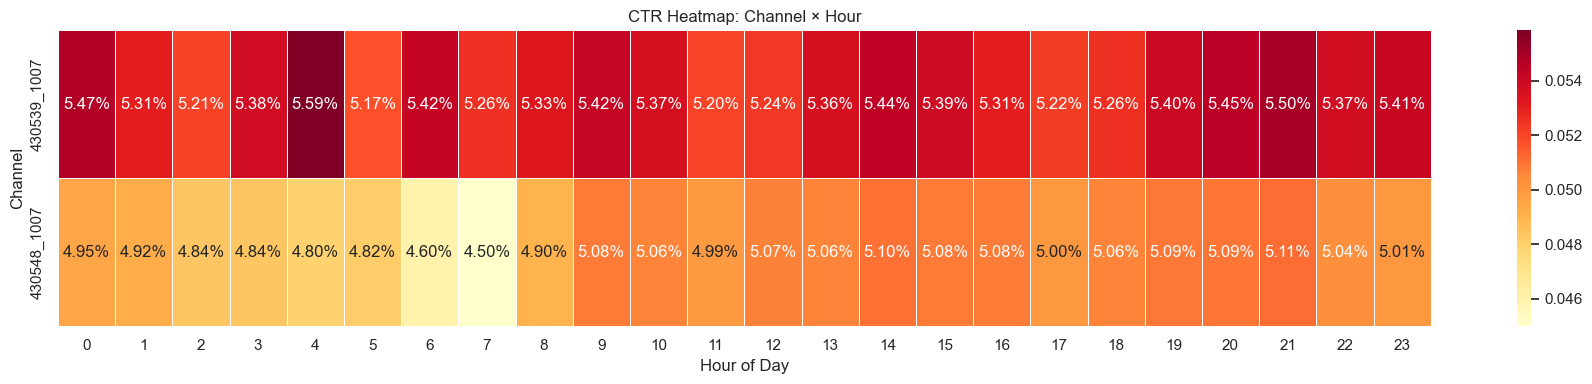

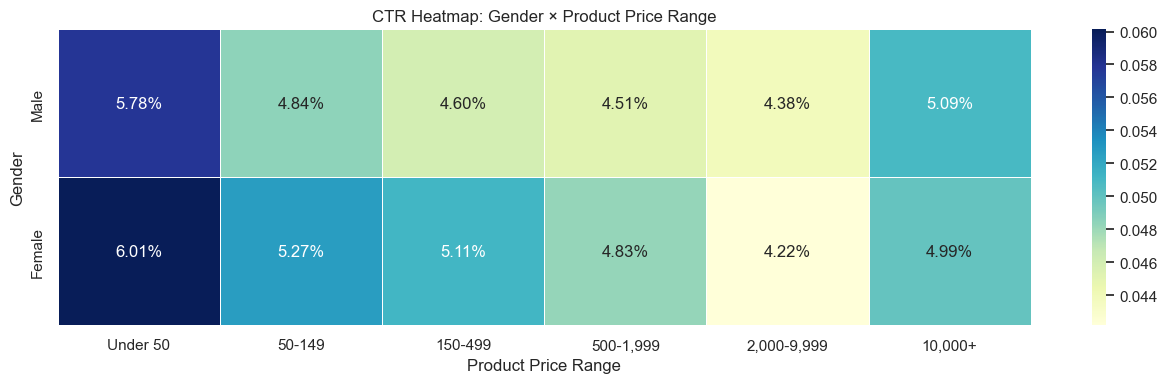

In [33]:
# Prepare Channel × Hour results

channel_hour_analysis = (
    channel_hour_metrics
    .reset_index()
)

channel_hour_analysis[
    [
        "impressions",
        "clicks"
    ]
] = (
    channel_hour_analysis[
        [
            "impressions",
            "clicks"
        ]
    ]
    .astype("int64")
)

channel_hour_analysis["ctr"] = (
    channel_hour_analysis["clicks"] /
    channel_hour_analysis["impressions"]
)

channel_baseline = (
    channel_hour_analysis
    .groupby("pid", as_index=False)
    .agg(
        channel_impressions=(
            "impressions",
            "sum"
        ),
        channel_clicks=(
            "clicks",
            "sum"
        )
    )
)

channel_baseline["channel_ctr"] = (
    channel_baseline["channel_clicks"] /
    channel_baseline["channel_impressions"]
)

channel_hour_analysis = (
    channel_hour_analysis
    .merge(
        channel_baseline[
            [
                "pid",
                "channel_ctr"
            ]
        ],
        on="pid",
        how="left"
    )
)

channel_hour_analysis["lift_vs_channel"] = (
    channel_hour_analysis["ctr"] /
    channel_hour_analysis["channel_ctr"] - 1
)

top_channel_hours = (
    channel_hour_analysis
    .sort_values(
        [
            "pid",
            "ctr"
        ],
        ascending=[
            True,
            False
        ]
    )
    .groupby(
        "pid",
        as_index=False
    )
    .head(3)
    .reset_index(drop=True)
)

print("Top 3 hours for each channel")

display(
    top_channel_hours.style.format({
        "impressions": "{:,.0f}",
        "clicks": "{:,.0f}",
        "ctr": "{:.4%}",
        "channel_ctr": "{:.4%}",
        "lift_vs_channel": "{:+.2%}"
    })
)


# Prepare Gender × Price results

gender_price_analysis = (
    gender_price_metrics
    .reset_index()
)

gender_price_analysis[
    [
        "impressions",
        "clicks"
    ]
] = (
    gender_price_analysis[
        [
            "impressions",
            "clicks"
        ]
    ]
    .astype("int64")
)

gender_price_analysis["ctr"] = (
    gender_price_analysis["clicks"] /
    gender_price_analysis["impressions"]
)

gender_price_analysis["gender_label"] = (
    gender_price_analysis[
        "final_gender_code"
    ]
    .map({
        1: "Male",
        2: "Female"
    })
)

gender_price_analysis["price_bin"] = (
    pd.Categorical(
        gender_price_analysis["price_bin"],
        categories=price_order,
        ordered=True
    )
)

gender_baseline = (
    gender_price_analysis
    .groupby(
        "gender_label",
        as_index=False
    )
    .agg(
        gender_impressions=(
            "impressions",
            "sum"
        ),
        gender_clicks=(
            "clicks",
            "sum"
        )
    )
)

gender_baseline["gender_ctr"] = (
    gender_baseline["gender_clicks"] /
    gender_baseline["gender_impressions"]
)

gender_price_analysis = (
    gender_price_analysis
    .merge(
        gender_baseline[
            [
                "gender_label",
                "gender_ctr"
            ]
        ],
        on="gender_label",
        how="left"
    )
)

gender_price_analysis["lift_vs_gender"] = (
    gender_price_analysis["ctr"] /
    gender_price_analysis["gender_ctr"] - 1
)

gender_price_analysis = (
    gender_price_analysis
    .sort_values(
        [
            "gender_label",
            "price_bin"
        ]
    )
    .reset_index(drop=True)
)

print("CTR by Gender and Product Price Range")

display(
    gender_price_analysis[
        [
            "gender_label",
            "price_bin",
            "impressions",
            "clicks",
            "ctr",
            "gender_ctr",
            "lift_vs_gender"
        ]
    ].style.format({
        "impressions": "{:,.0f}",
        "clicks": "{:,.0f}",
        "ctr": "{:.4%}",
        "gender_ctr": "{:.4%}",
        "lift_vs_gender": "{:+.2%}"
    })
)


# Channel × Hour heatmap

channel_hour_matrix = (
    channel_hour_analysis
    .pivot(
        index="pid",
        columns="hour",
        values="ctr"
    )
    .reindex(
        columns=range(24)
    )
)

fig, ax = plt.subplots(
    figsize=(18, 4)
)

sns.heatmap(
    channel_hour_matrix,
    annot=True,
    fmt=".2%",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax
)

ax.set_title("CTR Heatmap: Channel × Hour")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Channel")

plt.tight_layout()
plt.show()


# Gender × Price heatmap

gender_price_matrix = (
    gender_price_analysis
    .pivot(
        index="gender_label",
        columns="price_bin",
        values="ctr"
    )
    .reindex(
        index=[
            "Male",
            "Female"
        ],
        columns=price_order
    )
)

gender_price_matrix.columns = [
    price_label_mapping[str(column)]
    for column in gender_price_matrix.columns
]

fig, ax = plt.subplots(
    figsize=(13, 4)
)

sns.heatmap(
    gender_price_matrix,
    annot=True,
    fmt=".2%",
    cmap="YlGnBu",
    linewidths=0.5,
    ax=ax
)

ax.set_title(
    "CTR Heatmap: Gender × Product Price Range"
)

ax.set_xlabel("Product Price Range")
ax.set_ylabel("Gender")

plt.tight_layout()
plt.show()

## 6. 核心结论与业务建议

### 6.1 核心结论

1. **两个广告渠道的点击效率存在稳定差异。**

   渠道`430539_1007`的CTR为5.3578%，渠道`430548_1007`的CTR为5.0126%。两者相差0.3453个百分点，95%置信区间为0.3278至0.3627个百分点，统计检验结果显著。

2. **21点是兼顾点击效率和曝光规模的重点投放时段。**

   两个渠道在21点均表现较好。其中，渠道`430539_1007`在21点获得669,417次曝光，CTR为5.4991%；渠道`430548_1007`在21点获得1,212,493次曝光，CTR为5.1114%。

   渠道`430539_1007`在凌晨4点的CTR更高，但曝光量只有51,882次。相比之下，21点的结果具有更大的流量规模，更适合作为预算调整依据。

3. **女性用户的整体点击倾向高于男性用户。**

   女性用户CTR为5.2445%，男性用户CTR为4.8354%，两者相差0.4090个百分点。95%置信区间为0.3900至0.4281个百分点，说明该差异并非由一般样本波动造成。

4. **职业不是当前数据中的有效核心定向变量。**

   大学生与非学生用户的CTR仅相差0.0213个百分点，95%置信区间包含零，p值为0.2741。因此，没有充分证据说明两类用户的点击倾向存在稳定差异。

5. **低价商品在不同性别用户中均表现较好。**

   50元以下商品的整体CTR为5.9687%，比整体水平高16.04%。在女性和男性用户中，该价格区间的CTR分别为6.0128%和5.7775%，说明低价商品的点击优势并不是由单一性别群体造成的。

6. **高价商品的CTR整体较低。**

   商品价格从50元以下提高到2,000至9,999元时，CTR整体呈下降趋势。10,000元以上商品的CTR有所回升，但其曝光占比较低，因此不能据此认为超高价商品具有稳定的点击优势。

7. **部分高曝光品类具有较大的优化空间。**

   在满足至少20,000次曝光的152个品类中，品类`2468`的CTR最高，为8.4128%；品类`6281`的CTR最低，为3.2150%。

   品类`4505`和`4385`分别获得455,777次和331,271次曝光，但CTR仅为3.4890%和3.6040%。这两个品类同时具有较大的曝光规模和较弱的点击表现，应被优先纳入优化范围。

8. **品牌ID缺失组的差异不能直接解释为品牌效应。**

   品牌ID缺失组的CTR为5.5155%，品牌信息完整组为4.9749%，两者差异具有统计意义。但品牌ID缺失只代表数据中没有提供对应字段，并不等同于无品牌商品，因此不能得出“无品牌商品效果更好”的因果结论。

### 6.2 业务建议

* 在保留对照流量的情况下，逐步增加渠道`430539_1007`和21点时段的测试预算，并持续观察CTR变化。
* 针对女性用户和低价商品设计独立的广告素材与投放组合，通过A/B测试验证实际增量效果。
* 优先检查品类`4505`和`4385`的广告素材、用户定向、展示位置及商品价格，而不是只扩大高CTR、小流量品类的预算。
* 不建议仅根据职业字段制定重点用户定向策略。
* 高CTR但曝光量较小的时段和品类应采用逐步放量方式，避免扩大投放后CTR明显回落。
* 提高消费能力、新用户等级和品牌ID等字段的完整性，为后续用户细分和多维分析提供更可靠的数据基础。

## 7. 分析局限

* 数据仅覆盖八天，星期维度的结果可能受到具体日期、促销活动和短期流量变化影响。
* 同一用户或广告可能产生多次曝光，比例Z检验采用常规曝光层级近似，因此显著性结果需要谨慎解释。
* 商品品类仅提供品类ID，没有对应的品类名称，限制了具体业务含义的判断。
* 用户消费能力、新用户等级和品牌信息存在较多缺失值，可能影响部分细分结论。
* 数据不包含广告成本、订单和销售收入，因此无法计算转化率、CPA、ROI或ROAS。
* 当前分析基于观察性数据，只能说明变量之间存在相关关系，不能直接证明因果关系。